1. The more time a person spends on TikTok and Instagram, the less they sleep
and the higher their addiction score. TikTok has a stronger effect than Instagram.
2. Young users (<25) are more susceptible to digital addiction than adults (35+), and they show a stronger correlation between social media time and sleep deprivation.

## Imports 

In [89]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import RobustScaler, StandardScaler

sns.set_theme(style='whitegrid')
PINK = {
    'deep':    '#8B0A50',
    'magenta': '#C71585',
    'hot':     '#FF1493',
    'rose':    '#FF69B4',
    'light':   '#FFB6C1',
    'pale':    '#FFE4EC',
}
pink_palette = [PINK['hot'], PINK['magenta'], PINK['rose'], PINK['light'], PINK['deep']]
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=pink_palette)

## Data cleanup

In [6]:
data = pd.read_csv('data/data.csv')
data

,user_id,country,age,year,internet_penetration,mental_health_support_index,gdp_index,youth_population_ratio,baseline_addiction_pressure,tiktok_minutes_daily,...,addiction_pressure,attention_span_score,dopamine_dependency_score,impulsivity_index,sleep_hours,sleep_quality_index,ASI,MHRI,addiction_score,addiction_level
0,1,Philippines,59,2050,88.895513,64.347080,0.312067,0.310389,64.762693,242.853130,...,69.981792,77.479304,27.024835,60.044856,6.561778,7.912360,100.0,40.460626,63.512418,High
1,2,Netherlands,23,2035,57.950292,76.257045,0.460320,0.293134,37.592646,98.599951,...,56.862382,78.852713,25.376744,81.769114,9.400197,2.292106,100.0,79.424028,62.688372,High
2,3,Laos,26,2060,40.325805,55.846514,0.893658,0.183055,22.589595,127.221573,...,41.817693,83.573012,19.712386,99.613065,7.810417,2.308761,100.0,88.262729,59.856193,High
3,4,Bulgaria,50,2046,43.838044,28.390576,0.661523,0.155038,57.093084,140.528514,...,70.811984,83.437675,19.874790,86.935944,7.020033,4.512440,100.0,70.905771,59.937395,High
4,5,Zambia,24,2045,43.749943,81.413755,0.275186,0.457115,57.653485,187.748696,...,71.990949,71.993561,33.607727,45.275020,7.900621,4.265014,100.0,51.312439,66.803864,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,Cambodia,30,2019,88.112224,35.854704,0.930592,0.389052,73.468587,138.532061,...,88.124399,87.352146,15.177425,68.300175,7.762866,4.137675,100.0,63.461711,57.588712,High
9996,9997,Nepal,44,2021,75.276099,88.995532,0.335594,0.174699,26.671849,109.827675,...,34.390640,84.661070,18.406715,24.921506,6.227259,6.912484,100.0,27.898335,59.203358,High
9997,9998,Brazil,44,2039,75.320851,55.599948,0.918843,0.373100,69.587448,157.642548,...,73.780044,77.524906,26.970113,46.063910,8.612393,8.322962,100.0,31.417147,63.485057,High
9998,9999,Iceland,57,2022,41.499728,82.096050,0.698312,0.412805,78.463688,89.940360,...,79.496451,83.099185,20.280978,80.615419,4.786482,9.586895,100.0,42.373235,60.140489,High


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      10000 non-null  int64  
 1   country                      10000 non-null  str    
 2   age                          10000 non-null  int64  
 3   year                         10000 non-null  int64  
 4   internet_penetration         10000 non-null  float64
 5   mental_health_support_index  10000 non-null  float64
 6   gdp_index                    10000 non-null  float64
 7   youth_population_ratio       10000 non-null  float64
 8   baseline_addiction_pressure  10000 non-null  float64
 9   tiktok_minutes_daily         10000 non-null  float64
 10  instagram_minutes_daily      10000 non-null  float64
 11  night_usage_ratio            10000 non-null  float64
 12  scroll_velocity              10000 non-null  float64
 13  addiction_pressure          

In [8]:
data.shape[0]

10000

In [9]:
data.isna().sum()

user_id                        0
country                        0
age                            0
year                           0
internet_penetration           0
mental_health_support_index    0
gdp_index                      0
youth_population_ratio         0
baseline_addiction_pressure    0
tiktok_minutes_daily           0
instagram_minutes_daily        0
night_usage_ratio              0
scroll_velocity                0
addiction_pressure             0
attention_span_score           0
dopamine_dependency_score      0
impulsivity_index              0
sleep_hours                    0
sleep_quality_index            0
ASI                            0
MHRI                           0
addiction_score                0
addiction_level                0
dtype: int64

In [10]:
data = data.drop_duplicates()

In [11]:
data = data.drop(data[data['year'] > 2026].index)
data.head()

,user_id,country,age,year,internet_penetration,mental_health_support_index,gdp_index,youth_population_ratio,baseline_addiction_pressure,tiktok_minutes_daily,...,addiction_pressure,attention_span_score,dopamine_dependency_score,impulsivity_index,sleep_hours,sleep_quality_index,ASI,MHRI,addiction_score,addiction_level
18,19,China,46,2018,94.390580,36.943869,0.645441,0.374847,49.557506,58.792207,...,58.024148,86.402902,16.316518,32.436500,7.298723,6.613343,98.515875,33.151534,57.416196,High
19,20,Czechia,43,2025,42.740574,55.752311,0.704911,0.236706,27.024021,136.855216,...,34.913731,81.163815,22.603422,99.239768,8.095954,6.844116,100.000000,65.399305,61.301711,High
23,24,Belgium,42,2016,70.960629,33.059904,0.797193,0.210653,39.719873,17.959560,...,51.533919,88.551882,13.737742,25.943267,4.656685,5.274382,92.316799,36.599725,53.027271,High
31,32,Mozambique,15,2021,59.185816,66.198883,0.228754,0.431218,74.069481,120.175304,...,86.746832,87.301791,15.237851,57.658179,6.462717,4.929060,100.000000,54.183792,57.618926,High
33,34,Greece,34,2021,51.780753,77.261034,0.978408,0.344024,46.491830,34.378532,...,53.980710,91.484832,10.218201,66.078848,6.646852,7.004448,66.068766,48.017183,38.143484,Medium


## Data transformation

In [12]:
columns = ['user_id', 'age', 'year', 'tiktok_minutes_daily', 'instagram_minutes_daily', 'sleep_hours', 'addiction_score']
data2 = data[columns].copy()
data2.info()

<class 'pandas.DataFrame'>
Index: 2621 entries, 18 to 9998
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  2621 non-null   int64  
 1   age                      2621 non-null   int64  
 2   year                     2621 non-null   int64  
 3   tiktok_minutes_daily     2621 non-null   float64
 4   instagram_minutes_daily  2621 non-null   float64
 5   sleep_hours              2621 non-null   float64
 6   addiction_score          2621 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 163.8 KB


In [61]:
data2['total_minutes_daily'] = data2['tiktok_minutes_daily'] + data2['instagram_minutes_daily']
data2['sos_situation'] = ((data2['total_minutes_daily'] / 60) > 3).astype(int)
data2['age_group'] = pd.cut(data2['age'], bins=[0, 25, 35, 100], labels=['<25', '25-35', '>35'])
data2['sleep_deprived'] = (data2['sleep_hours'] < 7).astype(int)
data2['heavy_user'] = (data2['total_minutes_daily'] > data2['total_minutes_daily'].median()).astype(int)
data2

,user_id,age,year,tiktok_minutes_daily,instagram_minutes_daily,sleep_hours,addiction_score,total_minutes_daily,sos_situation,age_group,sleep_deprived,heavy_user,tiktok_minutes_daily_z,instagram_minutes_daily_z,total_minutes_daily_z,sleep_hours_z,addiction_score_z
0,19,46,2018,58.792207,104.372974,7.298723,57.416196,163.165180,0,>35,0,0,-1.419383,-0.079435,-1.299215,0.197344,-1.345519
1,20,43,2025,136.855216,89.179008,8.095954,61.301711,226.034224,1,>35,0,0,0.124344,-0.412720,-0.215871,0.733973,-0.139365
2,24,42,2016,17.959560,119.417856,4.656685,53.027271,137.377416,0,>35,1,0,-2.226865,0.250579,-1.743584,-1.581055,-2.707943
3,32,15,2021,120.175304,32.203208,6.462717,57.618926,152.378512,0,<25,1,0,-0.205508,-1.662504,-1.485088,-0.365386,-1.282587
4,47,47,2015,177.116215,108.167340,6.049868,64.264178,285.283555,1,>35,1,1,0.920522,0.003795,0.805100,-0.643281,0.780253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2171,9989,57,2018,102.116148,217.361252,6.414216,65.973870,319.477400,1,>35,1,1,-0.562635,2.399001,1.394320,-0.398032,1.310981
2172,9990,21,2015,142.742400,150.664773,7.696633,64.670359,293.407174,1,<25,0,1,0.240766,0.935991,0.945084,0.465184,0.906341
2173,9996,30,2019,138.532061,13.242186,7.762866,57.588712,151.774246,0,25-35,0,0,0.157505,-2.078420,-1.495501,0.509766,-1.291966
2174,9997,44,2021,109.827675,74.239479,6.227259,59.203358,184.067154,1,>35,1,0,-0.410136,-0.740424,-0.939037,-0.523876,-0.790743


In [16]:
data2.describe()

,user_id,age,year,tiktok_minutes_daily,instagram_minutes_daily,sleep_hours,addiction_score,total_minutes_daily,sos_situation,sleep_deprived,heavy_user
count,2621.000000,2621.000000,2621.000000,2621.000000,2621.000000,2621.000000,2621.000000,2621.000000,2621.000000,2621.000000,2621.000000
mean,5007.758871,35.532621,2020.629912,119.479992,100.598992,7.009292,58.535584,220.078983,0.700878,0.504388,0.499809
std,2887.986676,13.388990,3.449915,57.887198,49.458432,1.481694,9.208167,75.320234,0.457961,0.500076,0.500095
min,19.000000,13.000000,2015.000000,0.000000,0.000000,3.000000,5.889972,0.000000,0.000000,0.000000,0.000000
25%,2514.000000,24.000000,2018.000000,80.482906,67.156795,6.005609,58.098778,169.270398,0.000000,0.000000,0.000000
50%,4999.000000,35.000000,2021.000000,118.873065,100.001809,6.984021,60.958964,219.179278,1.000000,1.000000,0.000000
75%,7560.000000,47.000000,2024.000000,159.501140,133.794061,8.062127,63.680905,273.618093,1.000000,1.000000,1.000000
max,9999.000000,59.000000,2026.000000,335.320877,272.527739,10.000000,74.607130,492.142605,1.000000,1.000000,1.000000


In [66]:
num_cols = ['tiktok_minutes_daily', 'instagram_minutes_daily',
            'total_minutes_daily', 'sleep_hours', 'addiction_score']

def remove_outliers_iqr(df, cols, k=1.5):
    mask = pd.Series(True, index=df.index)
    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        mask &= df[col].between(q1 - k*iqr, q3 + k*iqr)
    return df[mask]

before = len(data2)
data2 = remove_outliers_iqr(data2, num_cols).reset_index(drop=True)
print(f'Удалено выбросов: {before - len(data2)} из {before}')

scaler = StandardScaler()
data2[[c + '_z' for c in num_cols]] = scaler.fit_transform(data2[num_cols])

data2['heavy_user'] = (data2['total_minutes_daily'] > data2['total_minutes_daily'].median()).astype(int)
data2['sleep_deprived'] = (data2['sleep_hours'] < 7).astype(int)

data2.head()

Удалено выбросов: 3 из 2155


,user_id,age,year,tiktok_minutes_daily,instagram_minutes_daily,sleep_hours,addiction_score,total_minutes_daily,sos_situation,age_group,sleep_deprived,heavy_user,tiktok_minutes_daily_z,instagram_minutes_daily_z,total_minutes_daily_z,sleep_hours_z,addiction_score_z
0,19,46,2018,58.792207,104.372974,7.298723,57.416196,163.165180,0,>35,0,0,-1.436170,-0.085539,-1.328134,0.203326,-1.418034
1,20,43,2025,136.855216,89.179008,8.095954,61.301711,226.034224,1,>35,0,0,0.116515,-0.420054,-0.230774,0.740707,-0.168146
2,32,15,2021,120.175304,32.203208,6.462717,57.618926,152.378512,0,<25,1,0,-0.215251,-1.674450,-1.516412,-0.360191,-1.352820
3,47,47,2015,177.116215,108.167340,6.049868,64.264178,285.283555,1,>35,1,1,0.917312,-0.002002,0.803405,-0.638474,0.784818
4,51,20,2015,173.520642,152.131417,6.840941,66.282603,325.652060,1,<25,1,1,0.845796,0.965925,1.508025,-0.105245,1.434103


## 5. Descriptive statistics (4+ numeric fields)

In [68]:
d = data[['tiktok_minutes_daily','instagram_minutes_daily','sleep_hours','addiction_score']].agg(['mean','median','std']).T
d

,mean,median,std
tiktok_minutes_daily,119.479992,118.873065,57.887198
instagram_minutes_daily,100.598992,100.001809,49.458432
sleep_hours,7.009292,6.984021,1.481694
addiction_score,58.535584,60.958964,9.208167


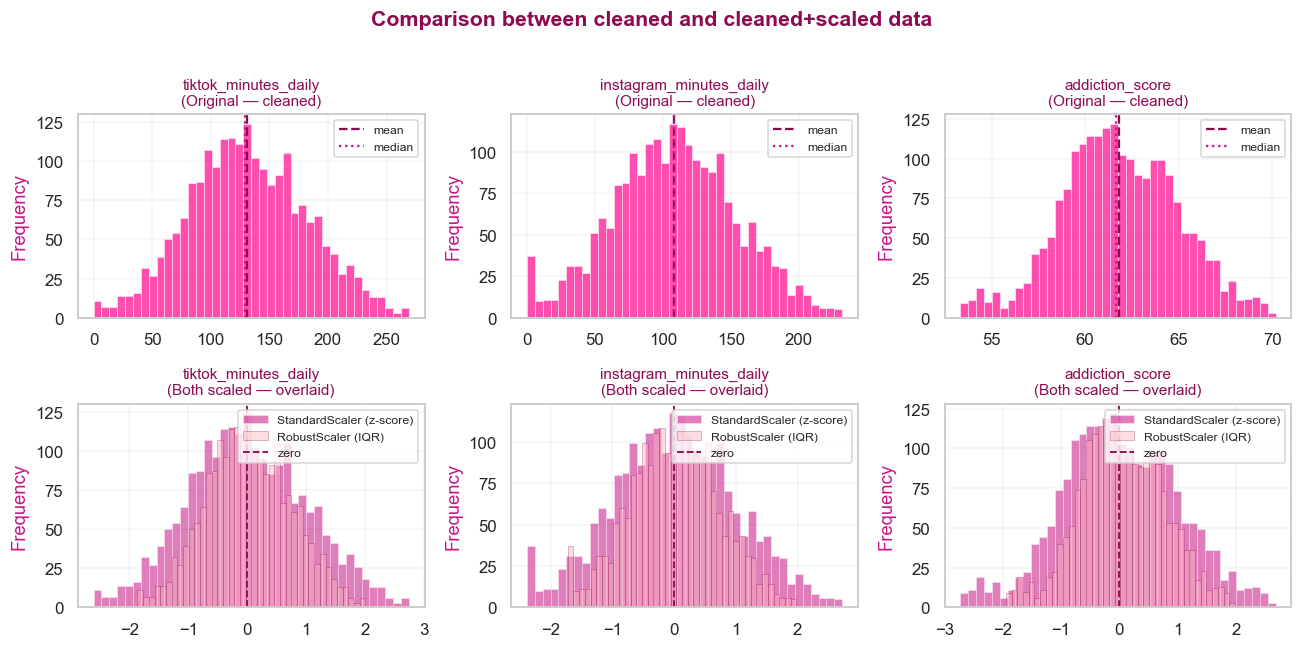

In [103]:
scaler_std    = StandardScaler()
robust_scaler = RobustScaler()

to_scale = ['tiktok_minutes_daily', 'instagram_minutes_daily', 'addiction_score']

data2[[c + '_std' for c in to_scale]] = scaler_std.fit_transform(data2[to_scale])
data2[[c + '_rs'  for c in to_scale]] = robust_scaler.fit_transform(data2[to_scale])

fig, axes = plt.subplots(
    2, 3,
    figsize = (12, 6),
    facecolor = 'white'
)

fig.suptitle(
    'Comparison between cleaned and cleaned+scaled data\n',
    fontsize = 14,
    color = PINK['deep'],
    fontweight = 'bold'
)

columns = ['tiktok_minutes_daily', 'instagram_minutes_daily', 'addiction_score']

for i, col in enumerate(columns):

    ax_top = axes[0, i]
    ax_top.hist(
        data2[col],
        bins = 40,
        color = PINK['hot'],
        alpha = 0.75,
        edgecolor = 'white',
        linewidth = 0.4
    )

    ax_top.axvline(
        data2[col].mean(),
        color = PINK['deep'],   ls = '--', lw = 1.5, label = 'mean'
    )
    ax_top.axvline(
        data2[col].median(),
        color = PINK['magenta'], ls = ':',  lw = 1.5, label = 'median'
    )
    ax_top.set_title(
        f'{col}\n(Original — cleaned)',
        fontsize = 10, color = PINK['deep']
    )
    ax_top.set_ylabel('Frequency', color = PINK['magenta'])
    ax_top.legend(fontsize=8)

    ax_bot = axes[1, i]
    ax_bot.hist(
        data2[col + '_std'],
        bins = 40,
        alpha = 0.55,
        color = PINK['magenta'],
        edgecolor = 'white',
        linewidth = 0.4,
        label = 'StandardScaler (z-score)'
    )
    ax_bot.hist(
        data2[col + '_rs'],
        bins = 40,
        alpha = 0.45,
        color = PINK['light'],
        edgecolor = PINK['deep'],
        linewidth = 0.4,
        label = 'RobustScaler (IQR)'
    )
    ax_bot.axvline(0, color = PINK['deep'], lw = 1.2, ls = '--', label = 'zero')
    ax_bot.set_title(
        f'{col}\n(Both scaled — overlaid)',
        fontsize = 10, color = PINK['deep']
    )
    ax_bot.set_ylabel('Frequency', color = PINK['magenta'])
    ax_bot.legend(fontsize = 8)

plt.tight_layout()
plt.show()

## Data visualizations

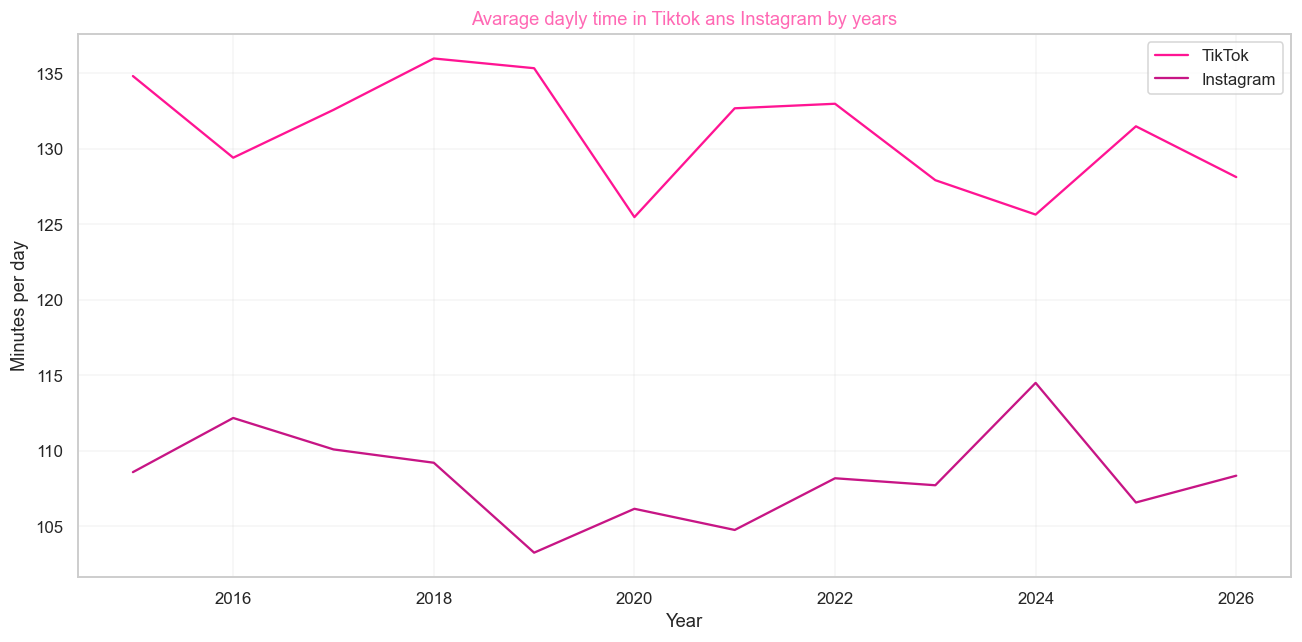

In [109]:
by_year = data2.groupby('year')[['tiktok_minutes_daily', 'instagram_minutes_daily']].mean()

plt.figure(figsize = (12, 6))
plt.plot(by_year.index, by_year['tiktok_minutes_daily'], color = PINK['hot'], label = 'TikTok')
plt.plot(by_year.index, by_year['instagram_minutes_daily'], color = PINK['magenta'], label = 'Instagram')
plt.title('Avarage dayly time in Tiktok ans Instagram by years')
plt.xlabel('Year')
plt.ylabel('Minutes per day')
plt.legend()
plt.tight_layout()
plt.show()

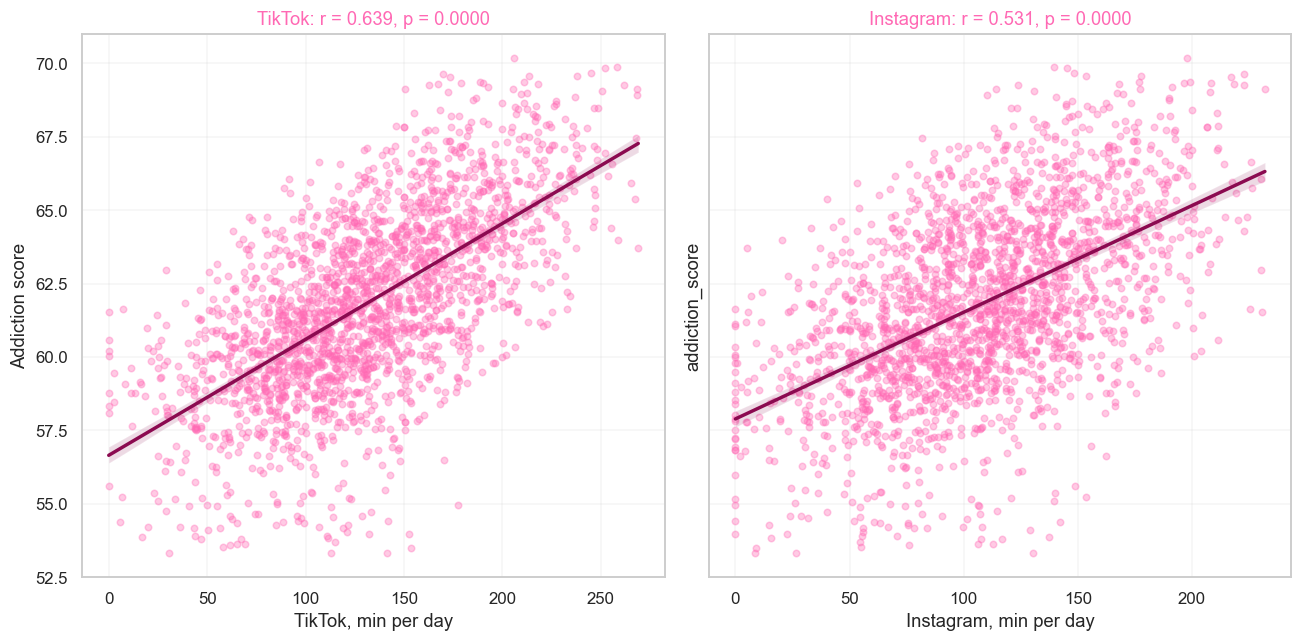

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for ax, col, title in zip(axes,['tiktok_minutes_daily', 'instagram_minutes_daily'], ['TikTok', 'Instagram']):
    sns.regplot(x = col, y = 'addiction_score', data = data2, ax = ax, scatter_kws = {'alpha': 0.35, 's': 18, 'color': PINK['rose']}, line_kws = {'color': PINK['deep']})
    r, p = pearsonr(data2[col], data2['addiction_score'])
    ax.set_title(f'{title}: r = {r:.3f}, p = {p:.4f}')
    ax.set_xlabel(f'{title}, min per day')

axes[0].set_ylabel('Addiction score')
plt.tight_layout()
plt.show()

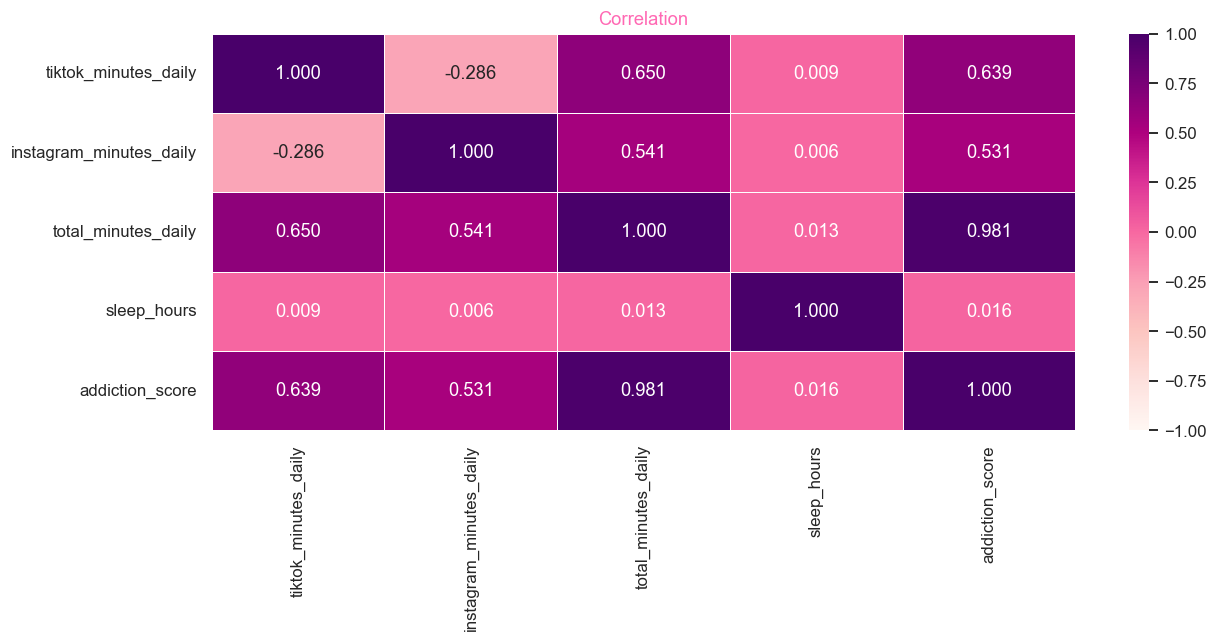

In [ ]:
plt.figure(figsize = (12, 6))
columns = ['tiktok_minutes_daily', 'instagram_minutes_daily', 'total_minutes_daily', 'sleep_hours', 'addiction_score']
sns.heatmap(data2[columns].corr(), annot = True, fmt = '.3f', cmap = 'RdPu', linewidths = 0.5, vmin = -1, vmax = 1)
plt.title('Correlation')
plt.tight_layout()
plt.show()

/var/folders/wk/q0mts90d38gch7vsc6z9ccwm0000gn/T/ipykernel_42391/3137161498.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/wk/q0mts90d38gch7vsc6z9ccwm0000gn/T/ipykernel_42391/3137161498.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['≤ Median', '> Median'])


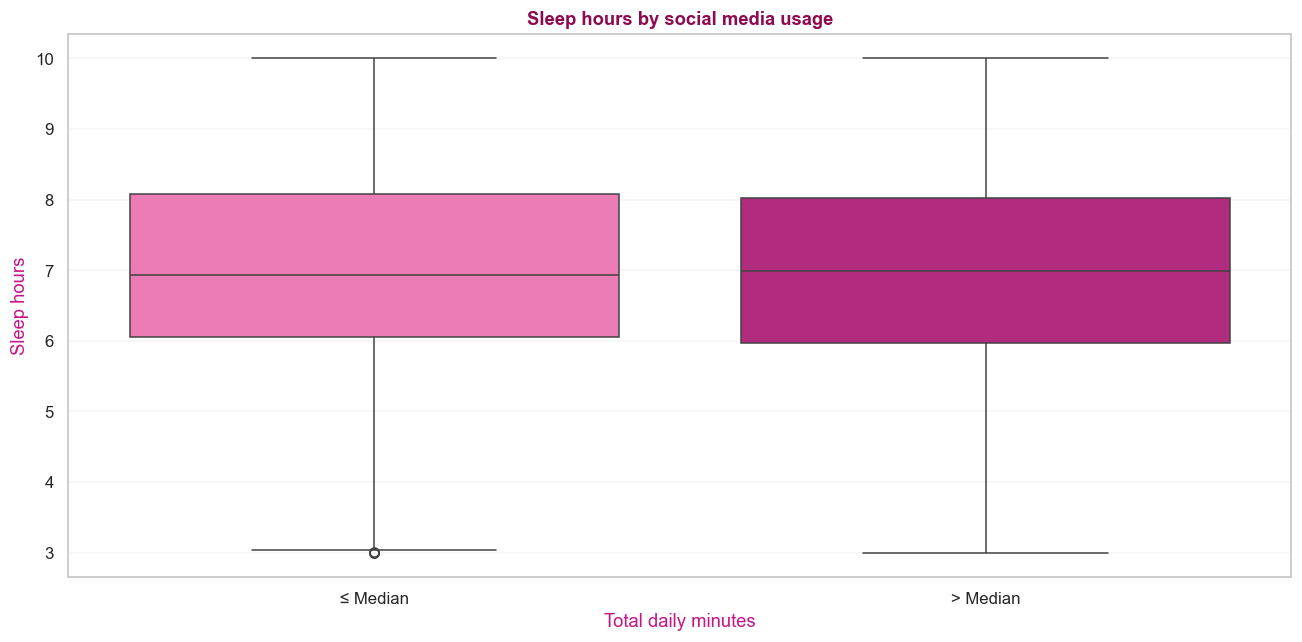

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (12, 6), facecolor = 'white')

sns.boxplot(
    x = 'heavy_user',
    y = 'sleep_hours',
    data = data2,
    palette = [pink_palette[2], pink_palette[1]],
    ax = ax
)
ax.set_xticklabels(['≤ Median', '> Median'])
ax.set_title('Sleep hours by social media usage', fontweight = 'bold', color = PINK['deep'])
ax.set_xlabel('Total daily minutes', color = PINK['magenta'])
ax.set_ylabel('Sleep hours', color = PINK['magenta'])


plt.tight_layout()
plt.show()

/var/folders/wk/q0mts90d38gch7vsc6z9ccwm0000gn/T/ipykernel_42391/3647639858.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='addiction_score', data=data2,


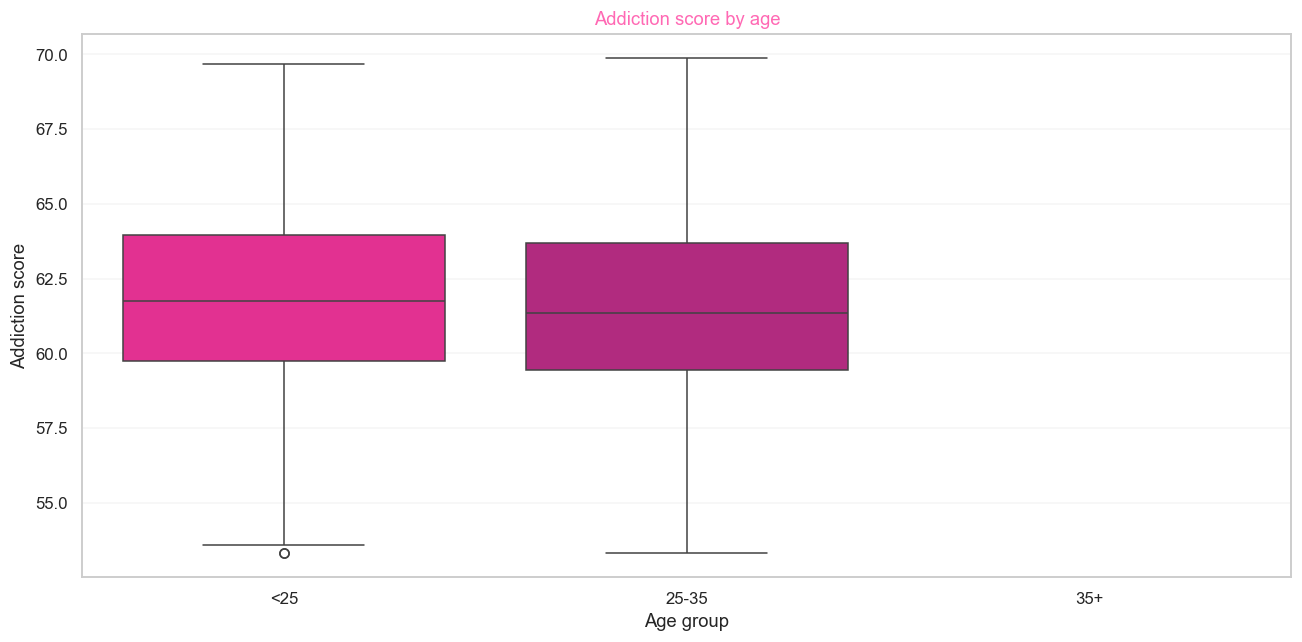

In [ ]:
plt.figure(figsize = (12, 6))
sns.boxplot(x = 'age_group', y = 'addiction_score', data = data2,
            order = ['<25', '25-35', '35+'],
            palette = [PINK['hot'], PINK['magenta'], PINK['light']])
plt.title('Addiction score by age')
plt.xlabel('Age group')
plt.ylabel('Addiction score')
plt.tight_layout()
plt.show()

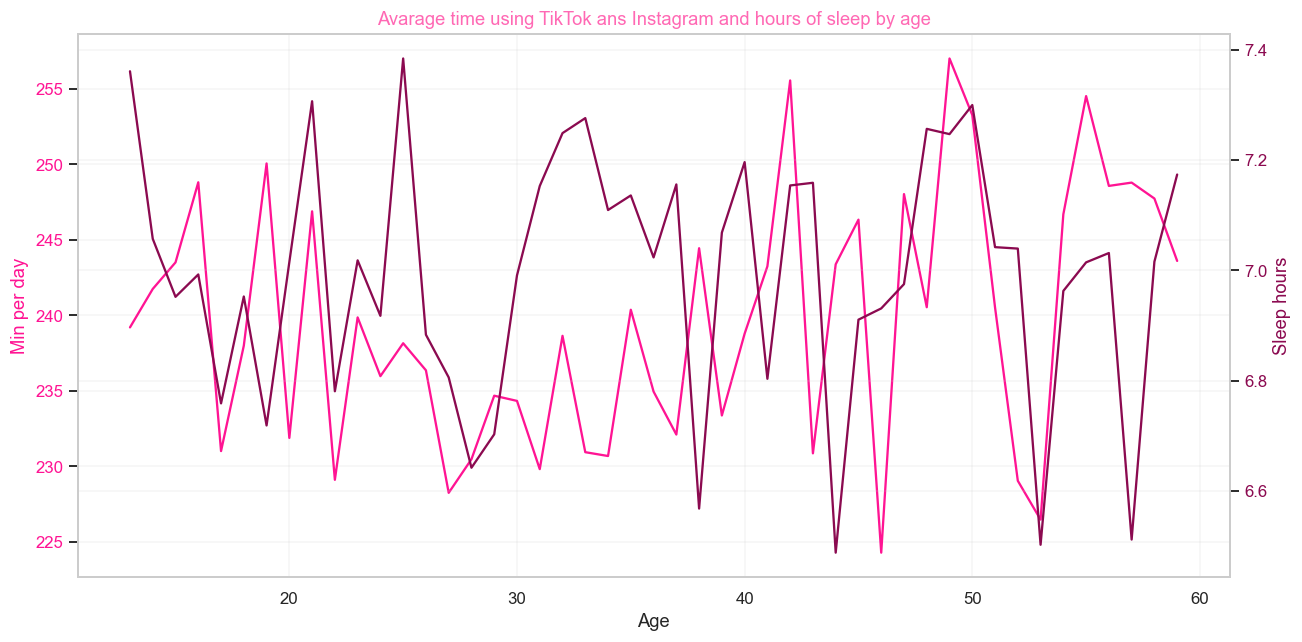

In [107]:
age_year = data2.groupby('age')[['total_minutes_daily', 'sleep_hours', 'addiction_score']].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(age_year.index, age_year['total_minutes_daily'], color = PINK['hot'], label = 'Minutes in TikTok/Instagram')
ax1.set_xlabel('Age')
ax1.set_ylabel('Min per day', color = PINK['hot'])
ax1.tick_params(axis = 'y', labelcolor = PINK['hot'])

ax2 = ax1.twinx()
ax2.plot(age_year.index, age_year['sleep_hours'], color = PINK['deep'], label = 'Sleep hours')
ax2.set_ylabel('Sleep hours', color = PINK['deep'])
ax2.tick_params(axis = 'y', labelcolor = PINK['deep'])

plt.title('Avarage time using TikTok ans Instagram and hours of sleep by age')
fig.tight_layout()
plt.show()

In [118]:
yearly_table = data2.groupby('year')['addiction_score'].agg(
    Mean='mean',
    Min='min',
    Max='max',
    Std='std',
    Count='count'
).round(2).reset_index()

yearly_table.style \
    .background_gradient(cmap='RdPu', subset=['Mean', 'Min', 'Max']) \
    .set_caption('📊 Addiction Score Statistics by Year') \
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12pt',
        'border-color': PINK['hot']
    }) \
    .set_table_styles([
        {'selector': 'caption',
         'props': [('color', PINK['hot']),
                   ('font-size', '14pt'),
                   ('font-weight', 'bold'),
                   ('padding', '10px')]},
        {'selector': 'th',
         'props': [('background-color', PINK['light']),
                   ('color', PINK['deep']),
                   ('font-weight', 'bold'),
                   ('text-align', 'center')]}
    ])

,year,Mean,Min,Max,Std,Count
0,2015,61.910000,53.340000,69.130000,3.480000,167
1,2016,61.920000,53.340000,68.620000,3.100000,185
2,2017,61.970000,53.810000,69.280000,2.910000,172
3,2018,62.140000,53.330000,70.170000,3.220000,169
4,2019,61.800000,53.840000,69.670000,3.060000,169
5,2020,61.460000,53.600000,69.380000,2.980000,173
6,2021,61.770000,53.530000,68.670000,3.120000,204
7,2022,61.900000,53.650000,69.640000,3.070000,178
8,2023,61.640000,53.640000,68.500000,3.000000,177
9,2024,61.870000,53.850000,69.290000,3.340000,175
